In [1]:
import json
import torch
import time
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from torch.utils.data import DataLoader, TensorDataset
from tensorflow.keras.preprocessing.sequence import pad_sequences

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/qfu1/.local/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-04-01 17:15:50.275896: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-01 17:15:50.285731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743552950.296858 2927740 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0

In [2]:
with open("/home/qfu1/ML_crystring/ML_crystring/CleanData/token_to_number_combined.json", "r") as f:
    token_to_number_combined = json.load(f)
with open("/home/qfu1/ML_crystring/ML_crystring/CleanData/number_to_token_combined.json", "r") as f:
    number_to_token_combined = json.load(f)

In [3]:
df = pd.read_json("/home/qfu1/ML_crystring/ML_crystring/CleanData/CleanData(Tokenized).json", orient="records")
df

,string,band_gap,energy_above_hull,tokens,tokenized
0,P 4bar n 2 Tb 4f 0.355 0.000 0.000,0.0000,0.000000,"[START, P, 4bar, n, 2, Tb, 4f, 3, 5, 5, 0, 0, ...","[13, 15, 101, 81, 47, 107, 58, 2, 8, 8, 1, 1, ..."
1,P 6bar 1 1 Eu 2g 0.000 0.000 0.545 C 2g 0.000 ...,0.0000,0.000000,"[START, P, 6bar, 1, 1, Eu, 2g, 0, 0, 0, 0, 0, ...","[13, 15, 89, 17, 17, 145, 152, 1, 1, 1, 1, 1, ..."
2,I 4bar c 2 Tl 4a 0.000 0.000 0.000 Cl 8f 0.000...,0.0000,0.000000,"[START, I, 4bar, c, 2, Tl, 4a, 0, 0, 0, 0, 0, ...","[13, 34, 101, 24, 47, 122, 27, 1, 1, 1, 1, 1, ..."
3,P m c 21 Kr 4c 0.595 0.217 0.468 Tb 2a 0.000 0...,0.0000,0.000000,"[START, P, m, c, 21, Kr, 4c, 5, 9, 5, 2, 1, 7,...","[13, 15, 11, 24, 104, 277, 33, 8, 10, 8, 6, 3,..."
4,P 3bar 1 c Co 2c 0.000 0.000 0.000,0.0000,0.000000,"[START, P, 3bar, 1, c, Co, 2c, 0, 0, 0, 0, 0, ...","[13, 15, 20, 17, 24, 72, 52, 1, 1, 1, 1, 1, 1,..."
...,...,...,...,...,...
19084,C m c m Ba 4c 0.000 0.14 0.000 Si 4c 0.000 0.4...,0.0000,0.000000,"[START, C, m, c, m, Ba, 4c, 0, 0, 0, 1, 4, 0, ...","[13, 40, 11, 24, 11, 129, 33, 1, 1, 1, 3, 9, 1..."
19085,C m c m V 8f 0.000 0.296 0.604 O 4c 0.000 0.76...,2.4212,0.032813,"[START, C, m, c, m, V, 8f, 0, 0, 0, 2, 9, 6, 6...","[13, 40, 11, 24, 11, 71, 38, 1, 1, 1, 6, 10, 4..."
19086,C m c m Na 4c 0.000 0.178 0.000 Na 4c 0.000 0....,0.0000,0.000000,"[START, C, m, c, m, Na, 4c, 0, 0, 0, 1, 7, 8, ...","[13, 40, 11, 24, 11, 106, 33, 1, 1, 1, 3, 5, 7..."
19087,C m c m Nb 4c 0.000 0.145 0.000 B 4c 0.000 0.4...,0.0000,0.000000,"[START, C, m, c, m, Nb, 4c, 0, 0, 0, 1, 4, 5, ...","[13, 40, 11, 24, 11, 85, 33, 1, 1, 1, 3, 9, 8,..."


In [4]:
my_input_sequences = []
y = []

for tokens in df['tokenized']:
    for i in range(1, len(tokens)):
        my_input_sequences.append(tokens[:i])
        y.append(tokens[i])

y = np.array(y).reshape(len(y), 1)
max_sequence_len = max([len(seq) for seq in my_input_sequences])
X = np.array(pad_sequences(my_input_sequences, maxlen=max_sequence_len, padding="pre"))

X = torch.tensor(X, dtype=torch.long)
y = torch.tensor(y, dtype=torch.long)
print(X.shape)
print(y.shape)

torch.Size([1139967, 638])
torch.Size([1139967, 1])


In [26]:
vocab_size = len(token_to_number_combined)+1
emb_dim = 128
hidden_size = 64
batch_size=512

In [27]:
train_size = int(0.8 * len(X))
test_size = len(X) - train_size
dataset = TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(LSTMModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.linear_layer = nn.Linear(in_features=hidden_size, out_features=vocab_size)
        self.conv_layer = nn.Conv1d(in_channels=max_sequence_len, out_channels=1, kernel_size=1)

    def forward(self, x):
        # torch.Size([batch_size, 434])
        embedding = self.embedding_layer(x)
        # torch.Size([batch_size, 434, emb_dim])
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        # torch.Size([batch_size, 434, hidden_size])
        linear_output = self.linear_layer(rnn_output)
        # torch.Size([512, 434, 249])
        linear_output = F.relu(linear_output)
        final_output = self.conv_layer(linear_output)
        # torch.Size([512, 1, 249])
        return final_output

In [15]:
def train_model(model, data_loader, criterion, optimizer, epochs):
    model.to(device)
    model.train()
    losses = []
    start_time = time.time()
    for epoch in range(epochs):
        total_loss = 0
        for Input, TrueOutput in data_loader:
            Input = Input.to(device)
            TrueOutput = TrueOutput.to(device)
            
            optimizer.zero_grad()
            outputs = model(Input)
            log_softmax = outputs.log_softmax(dim=2)

            loss = criterion(log_softmax.transpose(1, 2), TrueOutput)
            loss = loss.sum(dim=1).mean()
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(data_loader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 5 == 0:
            end_time = time.time()  # End time tracking
            training_time = end_time - start_time
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}, Time: {training_time:.4f}")
    return model, losses

In [16]:
lr=4e-3
wd=1e-5
epochs = 300
num_layers = 5

In [50]:
model = LSTMModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers).to(device)
criterion = nn.NLLLoss(reduction='none')
optimizer = torch.optim.Adam(model.parameters(), lr=lr,weight_decay=wd)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
model, losses = train_model(model, train_loader, criterion, optimizer, epochs)

Epoch 5/300, Loss: 3.3631, Time: 45.4241
Epoch 10/300, Loss: 2.2725, Time: 90.9370
Epoch 15/300, Loss: 2.1969, Time: 136.8967
Epoch 20/300, Loss: 2.1434, Time: 182.6364
Epoch 25/300, Loss: 2.0729, Time: 205.9013
Epoch 30/300, Loss: 1.9852, Time: 227.2540
Epoch 35/300, Loss: 1.9422, Time: 248.4433
Epoch 40/300, Loss: 1.9136, Time: 269.5792
Epoch 45/300, Loss: 1.8825, Time: 290.9351
Epoch 50/300, Loss: 1.8366, Time: 312.1122
Epoch 55/300, Loss: 1.7710, Time: 333.2694
Epoch 60/300, Loss: 1.7575, Time: 354.6746
Epoch 65/300, Loss: 1.6825, Time: 375.7817
Epoch 70/300, Loss: 1.6604, Time: 396.9179
Epoch 75/300, Loss: 1.6341, Time: 418.2698
Epoch 80/300, Loss: 1.6178, Time: 439.4263
Epoch 85/300, Loss: 1.6000, Time: 460.6110
Epoch 90/300, Loss: 1.6011, Time: 481.7866
Epoch 95/300, Loss: 1.6014, Time: 503.1916
Epoch 100/300, Loss: 1.5823, Time: 524.6461
Epoch 105/300, Loss: 1.5642, Time: 545.8209
Epoch 110/300, Loss: 1.5521, Time: 567.2061
Epoch 115/300, Loss: 1.5408, Time: 588.5870
Epoch 120/

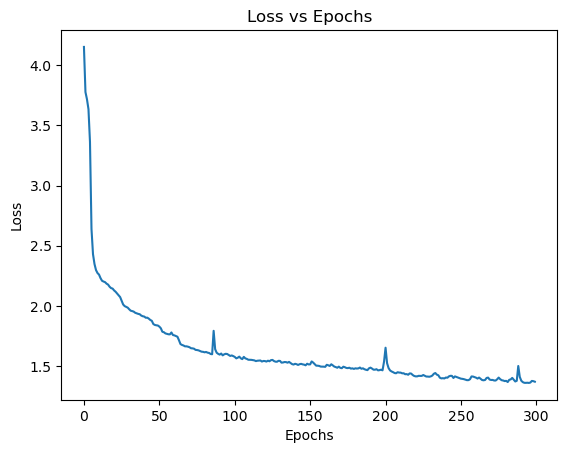

In [51]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()

In [17]:
# torch.save(model, f'/home/qfu1/TrainedModels/1kLSTM_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}_ed{emb_dim}.pth')
model = torch.load(f'/home/qfu1/TrainedModels/1kLSTM_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}_ed{emb_dim}.pth')
model.eval()

/tmp/ipykernel_818615/2059946817.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f'/home/qfu1/TrainedModels/1kLSTM_lr{lr}_wd{wd}_ep{epochs}_nl{num_lay

LSTMModel(
  (embedding_layer): Embedding(249, 128)
  (lstm_layer): LSTM(128, 64, num_layers=5, batch_first=True)
  (linear_layer): Linear(in_features=64, out_features=249, bias=True)
  (conv_layer): Conv1d(434, 1, kernel_size=(1,), stride=(1,))
)

In [18]:
data = df['tokenized']
data = pad_sequences(data, padding='post')

BravaisLattice = set(data[:, 1])
SymmInfo = set(data[:, 2:5].flatten())
ele = set(data[:, 5::11].flatten())
wyckoff = set(data[:, 6::11].flatten())
xyz = []
for start in range(7, data.shape[1], 11):
    xyz.append(data[:, start:start+3])
selected_columns = np.concatenate(xyz, axis=1)
xyz_dict = set(selected_columns.flatten())

# remove pad value
ele.discard(0)
wyckoff.discard(0)
xyz_dict.discard(0)

In [19]:
def LogicValid(input: list, output: list) -> bool:
    index = len(input)
    
    if index == 0:
        raise ValueError("index out of range")
    if index == 1 and int(output[0]) in BravaisLattice:
        return True
    elif 1 < index < 5 and int(output[0]) in SymmInfo:
        return True
    elif (index-5) % 11 == 0 and int(output[0]) in ele:
        return True
    elif (index - 6) % 11 == 0 and int(output[0]) in wyckoff:
        return True
    elif int(output[0]) in xyz_dict:
        return True
    else:
        return False

In [55]:
logic_count = 0
acc_count = 0
for x_test,y_test in test_dataset:
    x_test = x_test.to(device)
    output = model(x_test.unsqueeze(0))
    index = output.log_softmax(dim=2).argmax(dim=2)
    if LogicValid(x_test[x_test.nonzero(as_tuple=True)], index.squeeze(1)) == True:
        logic_count += 1
    if list(token_to_number_combined.keys())[index-1] == list(token_to_number_combined.keys())[y_test-1]:
        acc_count += 1

In [56]:
logic_count/test_size

0.9979608185856821

In [57]:
acc_count/test_size

0.485980627776564

In [20]:
def AutoGenerate(Start: torch.tensor, num_index: int, model: torch.nn.Module, device: torch.device) -> list:
    for _ in range(num_index):
        Start = Start.to(device)
        output = model(Start)
        probs = output.log_softmax(dim=2).flatten().exp()
        index = torch.multinomial(probs, num_samples=1)
        new_input = torch.cat((Start.flatten(), index.flatten()), dim=0).view(1, -1)
        new_input = new_input[new_input.nonzero(as_tuple=True)].cpu().numpy()
        Start = torch.tensor(pad_sequences([new_input], maxlen=max_sequence_len, padding="pre")).to(device)
    Pred_index = Start[Start.nonzero(as_tuple=True)].cpu().numpy()
    return Pred_index

In [21]:
def IndexToString(Pred_index: list)-> str:
    predicted_tokens = [number_to_token_combined[index] for index in Pred_index]
    cleaned_tokens = [token.replace('s2_', '').replace('s1_', '') for token in predicted_tokens]
    Pred_str = " ".join(cleaned_tokens)
    return Pred_str

In [22]:
def ChechUnique(df, Pred_str):
    for i in df['tokens']:
        if Pred_str in " ".join(i):
            return False
    return True # unique

In [23]:
def check_unique_pred_strings(df, model, max_sequence_len, n=20):
    pred_strings = []
    for _ in range(n):
        Start = torch.tensor(pad_sequences([[12]], maxlen=max_sequence_len, padding="pre")).to(device)
        Pred_index = AutoGenerate(Start, 26, model, device)
        Pred_str = IndexToString(Pred_index)
        pred_strings.append(Pred_str)
    return pred_strings

In [24]:
N=50
pred_strings = check_unique_pred_strings(df, model, max_sequence_len, n=N)
pred_strings

['START I m m a Ag 4b 0 0 4 0 0 0 0 0 0 Se 4a 0 0 0 0 0 0 9 0 0',
 'START P 2/c 1 1 Ba 4g 9 7 0 0 9 0 7 9 7 O 2b 9 0 0 0 5 9 6 1 6',
 'START P 4bar m c Ba 2a 0 0 0 4 0 0 0 0 0 Cd 8e 0 0 0 0 0 5 0 7 4',
 'START C n 1 1 Ba 8f 5 0 9 1 4 6 8 1 6 O 4e 2 8 4 0 6 1 9 0 Zn',
 'START P m m n Ce 2b 0 0 1 0 0 0 0 0 2 Ca 4f 0 0 0 0 0 0 0 0 0',
 'START I 4/m m m Rb 2a 6 9 0 0 0 0 0 0 0 Ti 4c 0 5 0 6 0 0 0 0 0',
 'START C m Hg m Ce 2a 1 2 3 0 3 0 0 0 0 As 4a 0 0 8 8 0 4 2 0 3',
 'START R 63/m m 1 K 3b 1 6 0 0 0 0 3 2 3 END 3a 0 0 0 0 0 0 8 0 0',
 'START I m 3bar 1 Ba 12e 0 0 3 0 0 0 0 0 0 C 24g 0 0 7 4 3 5 1 0 5',
 'START I a 3bar 1 Be 4g 0 1 0 0 0 0 0 0 0 O 48f 0 0 5 0 0 0 0 0 0',
 'START F m 3bar m Zr 4a 0 0 0 0 0 0 0 0 3 C 4b 3 0 0 0 0 0 0 0 0',
 'START R m c 1 Ba 18e 0 0 0 0 0 0 0 7 0 Mo Mo 0 0 1 0 3 0 0 0 4',
 'START P 2/c 1 1 K 2e 5 2 6 5 2 0 0 1 0 Ba 2e 4 0 9 0 8 9 0 0 1',
 'START I 42/m 3bar 1 Ba 2c 2 0 5 0 0 0 0 0 0 Fe 2a 0 7 0 7 0 0 0 3 0',
 'START I 3bar m m Ba 8c 0 4 0 0 0 0 0 6 0 Cs 4a 

In [25]:
count = 0
for Pred_str in pred_strings:
    if ChechUnique(df, Pred_str):
        count += 1

In [26]:
count/N

0.98

In [27]:
len(set(pred_strings))/N

1.0

In [28]:
import sympy as sp
from doped.utils.symmetry import get_wyckoff_dict_from_sgn

In [29]:
from ase.spacegroup import Spacegroup
spacegroup_names = []
for i in range(1, 231):
    name = Spacegroup(i).symbol
    name = name.replace('-1', '1bar').replace('-6', '6bar').replace('-3', '3bar').replace('-4', '4bar')
    parts = name.split()
    parts += ['1'] * (4 - len(parts)) 
    spacegroup_names.append(' '.join(parts))

In [55]:
count = 0

for String in pred_strings:
    valid = True
    print(f"\nPredict String: {String}")
    String_spacegroup = ' '.join(String.split()[1:5])
    if String_spacegroup in spacegroup_names:
        String_spacegroupNumber = spacegroup_names.index(String_spacegroup)+1
        print(f"Spacegroup found:\n\tName: {String_spacegroup}\n\tNumber: {String_spacegroupNumber}")

        # Wyckoff
        wyckoff = get_wyckoff_dict_from_sgn(String_spacegroupNumber)
        temp = np.array(String.split()[5:]).reshape(len(np.array(String.split()[5:]))//11, 11)
        print(temp)
        WY = []
        XYZ = [[],[],[]]
        
        for idx,i in enumerate(temp):
            if np.isin(i[2:], np.arange(0,10).astype(str)).all():
                WY.append(i[1])
                XYZ[0].append(float("0."+''.join(i[2:5])))
                XYZ[1].append(float("0."+''.join(i[5:6])))
                XYZ[2].append(float("0."+''.join(i[8:])))
            else:
                print(f"{idx}_XYZ value error")
                valid = False

        # print(WY, XYZ)
        for idx, wy in enumerate(WY):
            if wy in wyckoff:
                print(f"{idx}_Wyckoff found: \tName: {wy}")
                print(wyckoff[wy][0])
                
                # check XYZ Value
                for ith, sym in enumerate(sp.symbols('x y z')):
                    if not any(sym in j.free_symbols for j in wyckoff[wy][0]):
                        # x y z is not involved
                        valid = XYZ[ith][idx] == 0
                        print(valid)
                
            else:
                print(f"{idx}_Wyckoff not found for extracted name: {wy}")
                valid = False
    else:
        print(f"Spacegroup not found for extracted name: {String_spacegroup}")
        valid = False
    if valid == True:
        count+=1


Predict String: START I m m a Ag 4b 0 0 4 0 0 0 0 0 0 Se 4a 0 0 0 0 0 0 9 0 0
Spacegroup found:
	Name: I m m a
	Number: 74
[['Ag' '4b' '0' '0' '4' '0' '0' '0' '0' '0' '0']
 ['Se' '4a' '0' '0' '0' '0' '0' '0' '9' '0' '0']]
0_Wyckoff found: 	Name: 4b
[0, 0, 1/2]
False
True
True
1_Wyckoff found: 	Name: 4a
[0, 0, 0]
True
True
False

Predict String: START P 2/c 1 1 Ba 4g 9 7 0 0 9 0 7 9 7 O 2b 9 0 0 0 5 9 6 1 6
Spacegroup found:
	Name: P 2/c 1 1
	Number: 13
[['Ba' '4g' '9' '7' '0' '0' '9' '0' '7' '9' '7']
 ['O' '2b' '9' '0' '0' '0' '5' '9' '6' '1' '6']]
0_Wyckoff found: 	Name: 4g
[x, y, z]
1_Wyckoff found: 	Name: 2b
[1/2, 1/2, 0]
False
True
False

Predict String: START P 4bar m c Ba 2a 0 0 0 4 0 0 0 0 0 Cd 8e 0 0 0 0 0 5 0 7 4
Spacegroup not found for extracted name: P 4bar m c

Predict String: START C n 1 1 Ba 8f 5 0 9 1 4 6 8 1 6 O 4e 2 8 4 0 6 1 9 0 Zn
Spacegroup not found for extracted name: C n 1 1

Predict String: START P m m n Ce 2b 0 0 1 0 0 0 0 0 2 Ca 4f 0 0 0 0 0 0 0 0 0
Spacegro

In [56]:
count

10